In [1]:
import time
from datetime import datetime, timedelta
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from lightgbm import early_stopping, log_evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error

import joblib

from dotenv import load_dotenv
load_dotenv()

True

## Модель прогноза приоритетной комиссии на следующий блок

In [2]:
df_1block = pd.read_parquet("data/models_datasets/priority/priority_next_block.parquet")
df_1block.sort_values('height', ascending=True, inplace=True)
df_1block

,height,priority_min,priority_p25,priority_p50,priority_p90,priority_p95,priority_max,gas_limit,gas_used,transaction_count,...,util_lag_5,priority_lag_10,util_lag_10,priority_ma_5,priority_vol_5,priority_ma_10,priority_vol_10,priority_ma_20,priority_vol_20,target
0,22270687,0,77352978,500000000,1646946205,2000000000,74646946205,35964503,20185991,244,...,0.997814,1.000000e+09,0.439653,6.310355e+08,7.784127e+08,576358556.3,5.741276e+08,5.932910e+08,4.899063e+08,2.000000e+09
1,22270688,0,1000000001,2000000000,6448102449,14274139408,112030802128,35999623,13157365,122,...,0.269543,1.000000e+08,0.480725,1.011088e+09,9.073713e+08,766358556.3,6.996380e+08,6.432910e+08,5.769053e+08,1.500000e+09
2,22270689,0,1000000000,1500000000,5010000000,5661206682,16000000000,36000000,1167429,26,...,0.490839,5.911057e+08,0.475502,1.252288e+09,8.257153e+08,857247987.4,7.326017e+08,6.738923e+08,6.060626e+08,1.015782e+09
3,22270690,0,694184931,1015781581,2769187500,5010000000,44694084931,35964845,35958003,182,...,0.080589,2.422809e+08,0.299566,1.403156e+09,6.495333e+08,934598057.3,7.005922e+08,7.246814e+08,5.889371e+08,1.000000e+09
4,22270691,0,600000000,1000000000,3000000000,5600849255,26612693820,35999965,27614029,116,...,0.168027,6.750213e+08,0.999824,1.203156e+09,5.687457e+08,967095928.1,6.947263e+08,7.696662e+08,5.728769e+08,1.000000e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2616591,24888656,0,2000000,66659412,2000000000,2009791343,5000000000,60000000,48632923,180,...,0.998324,7.900000e+07,0.219526,4.203775e+07,2.801327e+07,33349965.4,2.945525e+07,8.083686e+07,1.467211e+08,4.001166e+06
2616592,24888657,0,137500,4001166,2000000000,2000000000,4945199664,60000000,32542067,239,...,0.464546,4.331932e+06,0.999727,2.745775e+07,2.401779e+07,33316888.8,2.949162e+07,5.603692e+07,1.092847e+08,6.422989e+06
2616593,24888658,0,137500,6422989,2000000000,2995464366,9552622506,60000000,9933771,98,...,0.370248,2.307491e+07,0.397202,2.474235e+07,2.577496e+07,31651696.7,3.058405e+07,5.610141e+07,1.092535e+08,5.000000e+07
2616594,24888659,0,4700593,50000000,2000000000,2000000000,10375995280,59941408,21864727,185,...,0.586974,5.228458e+06,0.165454,3.169494e+07,2.721810e+07,36128850.9,2.954559e+07,5.465141e+07,1.091259e+08,5.057452e+06


In [3]:
df_1block.columns

Index(['height', 'priority_min', 'priority_p25', 'priority_p50',
       'priority_p90', 'priority_p95', 'priority_max', 'gas_limit', 'gas_used',
       'transaction_count', 'base_fee_per_gas', 'last_eth_price',
       'block_utilization', 'gas_pressure', 'tx_per_gas', 'priority_spread',
       'priority_tail', 'fee_ratio', 'fee_diff', 'month', 'day', 'hour',
       'day_of_week', 'is_weekend', 'priority_lag_1', 'util_lag_1',
       'priority_lag_2', 'util_lag_2', 'priority_lag_3', 'util_lag_3',
       'priority_lag_5', 'util_lag_5', 'priority_lag_10', 'util_lag_10',
       'priority_ma_5', 'priority_vol_5', 'priority_ma_10', 'priority_vol_10',
       'priority_ma_20', 'priority_vol_20', 'target'],
      dtype='object')

In [4]:
drop_cols = [
    "height"
]

df_1block = df_1block.drop(columns=drop_cols)

In [5]:
target_column_name = "target"

time-based split 

Нельзя делать train_test_split - используем хронологическое разделение.

In [6]:
train_size_1block = int(len(df_1block) * 0.8)
val_size_1block = int(len(df_1block) * 0.1)

train_1block = df_1block.iloc[:train_size_1block]
val_1block = df_1block.iloc[train_size_1block:train_size_1block + val_size_1block]
test_1block = df_1block.iloc[train_size_1block + val_size_1block:]

In [7]:
X_train_1block = train_1block.drop(columns=[target_column_name])
y_train_1block = train_1block[target_column_name]

X_val_1block = val_1block.drop(columns=[target_column_name])
y_val_1block = val_1block[target_column_name]

X_test_1block = test_1block.drop(columns=[target_column_name])
y_test_1block = test_1block[target_column_name]

In [10]:
lgbm_model = LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.01,
    max_depth=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm_model.fit(
    X_train_1block,
    y_train_1block,
    eval_set=[(X_val_1block, y_val_1block)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(50)  # вывод каждые 50 итераций
    ]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034341 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8737
[LightGBM] [Info] Number of data points in the train set: 2093276, number of used features: 39
[LightGBM] [Info] Start training from score 376412291.609032
Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 1.02909e+09	valid_0's l2: 1.05903e+18
[100]	valid_0's rmse: 1.02255e+09	valid_0's l2: 1.0456e+18
Early stopping, best iteration is:
[99]	valid_0's rmse: 1.02247e+09	valid_0's l2: 1.04544e+18


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,50
,learning_rate,0.01
,n_estimators,5000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [11]:
lgbm_pred = lgbm_model.predict(X_test_1block)

lgbm_mae = mean_absolute_error(y_test_1block, lgbm_pred)
lgbm_rmse = np.sqrt(mean_squared_error(y_test_1block, lgbm_pred))

print("MAE:", lgbm_mae)
print("RMSE:", lgbm_rmse)

MAE: 278338250.18527555
RMSE: 5472736095.108252


In [12]:
lgbm_importance = pd.Series(
    lgbm_model.feature_importances_,
    index=X_train_1block.columns
).sort_values(ascending=False)

print(lgbm_importance.head(20))

priority_ma_20       281
gas_limit            175
priority_ma_10       162
base_fee_per_gas     161
priority_p90         156
block_utilization    146
util_lag_1           145
fee_ratio            141
priority_p95         135
priority_lag_1       120
util_lag_5           119
priority_p25         113
last_eth_price       107
tx_per_gas           100
priority_ma_5         98
transaction_count     90
gas_used              84
priority_p50          69
priority_max          61
util_lag_2            52
dtype: int32


Сравнение с бейзлайном (что если просто предсказывать предыдущее значение)

In [13]:
baseline_pred_1block = X_test_1block["priority_lag_1"]

mae_baseline = mean_absolute_error(y_test_1block, baseline_pred_1block)

print("Baseline MAE:", mae_baseline)
print("Model MAE:", lgbm_mae)

Baseline MAE: 248982765.05167374
Model MAE: 278338250.18527555


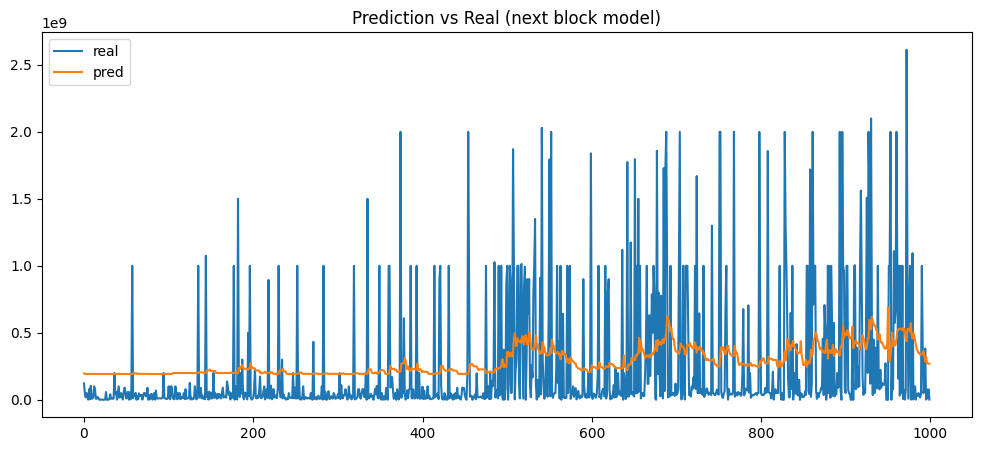

In [14]:
plt.figure(figsize=(12,5))
plt.plot(y_test_1block.values[:1000], label="real")
plt.plot(lgbm_pred[:1000], label="pred")
plt.legend()
plt.title("Prediction vs Real (next block model)")
plt.show()

In [15]:
joblib.dump(lgbm_model, 'models/priority/next_block_priority_lgbm.pkl')

['models/priority/next_block_priority_lgbm.pkl']

XGBoost

In [ ]:
xgboost = XGBRegressor(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist",
    eval_metric="rmse",   
    early_stopping_rounds=50
)

xgboost.fit(
    X_train_1block,
    y_train_1block,
    eval_set=[(X_val_1block, y_val_1block)],
    verbose=10
)

[0]	validation_0-rmse:1054759756.04846


In [ ]:
pred = xgboost.predict(X_test_1block)

mae = mean_absolute_error(y_test_1block, pred)
rmse = np.sqrt(mean_squared_error(y_test_1block, pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 183975256.1169506
RMSE: 198062751.44222742


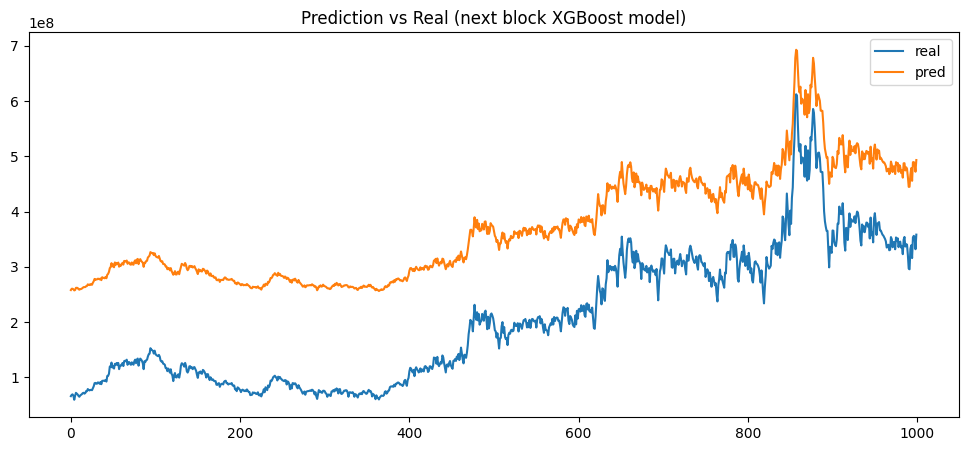

In [39]:
plt.figure(figsize=(12,5))
plt.plot(y_test_1block.values[:1000], label="real")
plt.plot(pred[:1000], label="pred")
plt.legend()
plt.title("Prediction vs Real (next block XGBoost model)")
plt.show()

## Модель прогноза приоритетной комиссии через 10 минут

In [8]:
df_10m = pd.read_parquet("data/models_datasets/priority/priority_10m.parquet")
df_10m.sort_values('height', ascending=True, inplace=True)
df_10m

,height,priority_min,priority_p25,priority_p50,priority_p90,priority_p95,priority_max,gas_limit,gas_used,transaction_count,...,priority_lag_50,priority_ma_10,priority_vol_10,priority_ma_20,priority_vol_20,priority_ma_50,priority_vol_50,spread_change,tail_change,target
0,22270718,0,79000000,617048972,2000000000,3054140105,25617048972,35929657,7269892,79,...,1.000000e+09,748316305.0,5.601132e+08,5.751585e+08,4.914366e+08,6.658535e+08,5.127358e+08,0.306246,-0.941618,5.000000e+08
1,22270719,0,1014347079,2000000000,3000000000,4382438338,63558709546,35964743,29406516,61,...,8.879744e+08,933298738.8,6.403381e+08,6.405669e+08,5.857826e+08,6.880940e+08,5.456297e+08,-0.156496,0.054917,5.000000e+08
2,22270720,3081300,8682676,198046190,2000000000,2199704400,6758975096,35999863,10224862,212,...,0.000000e+00,903103357.8,6.694963e+08,6.254692e+08,5.934374e+08,6.920549e+08,5.412338e+08,-0.555187,-0.817440,5.000000e+08
3,22270721,0,4401860,100000000,2000000000,3296156494,17638056758,36000000,13381157,149,...,1.003024e+08,832350787.0,7.164579e+08,5.819692e+08,5.987163e+08,6.920489e+08,5.412405e+08,0.457785,-0.726415,1.000000e+09
4,22270722,0,12445308,102208345,2000000000,2000000000,19649666195,36000000,30617794,291,...,5.000000e+08,642571621.5,6.172835e+08,5.766108e+08,6.026928e+08,6.840930e+08,5.470139e+08,-0.762776,1.526952,1.028922e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2591233,24888607,0,1231925,15000000,2000000000,2000000000,9551363953,60000000,47892205,256,...,9.537710e+08,90175631.2,1.704031e+08,8.085003e+07,1.551203e+08,1.350951e+08,3.407941e+08,-0.005590,2.672433,4.001166e+06
2591234,24888608,0,1000000,15587414,2000000000,2100000001,5000000000,60000000,36445243,205,...,8.394723e+06,91416036.0,1.697434e+08,7.831135e+07,1.557840e+08,1.352390e+08,3.407410e+08,0.043868,-0.033333,6.422989e+06
2591235,24888609,0,137500,7367481,2000000000,2036000000,9513573418,60000000,38226019,187,...,1.000000e+08,36023263.8,4.070158e+07,7.847344e+07,1.557044e+08,1.333863e+08,3.411881e+08,0.318403,1.578474,5.000000e+07
2591236,24888610,0,79000000,1000000000,2036000000,4958668337,6942413860,60000000,7076279,56,...,2.200000e+07,126023263.8,3.089530e+08,1.279734e+08,2.571249e+08,1.529463e+08,3.620672e+08,1.083510,-0.338751,5.057452e+06


In [9]:
drop_cols = [
    "height"
]

df_10m = df_10m.drop(columns=drop_cols)

In [10]:
train_size_10m = int(len(df_10m) * 0.8)
val_size_10m = int(len(df_10m) * 0.1)

train_10m = df_10m.iloc[:train_size_10m]
val_10m = df_10m.iloc[train_size_10m:train_size_10m + val_size_10m]
test_10m = df_10m.iloc[train_size_10m + val_size_10m:]

In [11]:
X_train_10m = train_10m.drop(columns=[target_column_name])
y_train_10m = train_10m[target_column_name]

X_val_10m = val_10m.drop(columns=[target_column_name])
y_val_10m = val_10m[target_column_name]

X_test_10m = test_10m.drop(columns=[target_column_name])
y_test_10m = test_10m[target_column_name]

In [12]:
lgbm_model_10m = LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.01,
    max_depth=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm_model_10m.fit(
    X_train_10m,
    y_train_10m,
    eval_set=[(X_val_10m, y_val_10m)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(50)  # вывод каждые 50 итераций
    ]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034153 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7971
[LightGBM] [Info] Number of data points in the train set: 2072990, number of used features: 36
[LightGBM] [Info] Start training from score 376211466.241617
Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 1.03626e+09	valid_0's l2: 1.07384e+18
Early stopping, best iteration is:
[49]	valid_0's rmse: 1.03614e+09	valid_0's l2: 1.07359e+18


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,50
,learning_rate,0.01
,n_estimators,5000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [13]:
lgbm_pred = lgbm_model_10m.predict(X_test_10m)

lgbm_mae = mean_absolute_error(y_test_10m, lgbm_pred)
lgbm_rmse = np.sqrt(mean_squared_error(y_test_10m, lgbm_pred))

print("MAE:", lgbm_mae)
print("RMSE:", lgbm_rmse)

MAE: 320400073.18450963
RMSE: 5088101149.081248


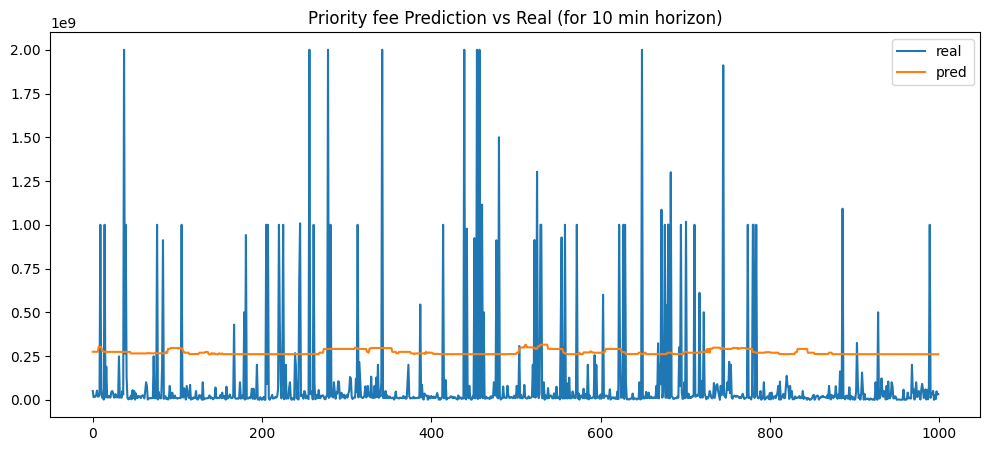

In [14]:
plt.figure(figsize=(12,5))
plt.plot(y_test_10m.values[:1000], label="real")
plt.plot(lgbm_pred[:1000], label="pred")
plt.legend()
plt.title("Priority fee Prediction vs Real (for 10 min horizon)")
plt.show()

In [15]:
joblib.dump(lgbm_model_10m, 'models/priority/10m_priority_lgbm.pkl')

['models/priority/10m_priority_lgbm.pkl']

## Модель прогноза комиссии через 1 час

In [16]:
df_1h = pd.read_parquet("data/models_datasets/priority/priority_1h.parquet")
df_1h.sort_values('height', ascending=True, inplace=True)
df_1h

,height,priority_min,priority_p25,priority_p50,priority_p90,priority_p95,priority_max,gas_limit,gas_used,transaction_count,...,priority_lag_300,priority_ma_50,priority_vol_50,priority_ma_100,priority_vol_100,priority_ma_300,priority_vol_300,spread_ma_50,tail_ma_50,target
0,22270970,0,4401858,115000000,2000000000,2000000000,51467971813,35999931,31371907,179,...,1.000000e+09,6.079286e+08,3.633382e+08,6.168141e+08,3.602964e+08,5.768471e+08,4.096600e+08,2.933134e+09,4.075712e+10,1.000000e+09
1,22270971,0,56615987,500000000,4000000000,4810905788,42792572317,36000000,19096262,175,...,8.879744e+08,5.817776e+08,3.196645e+08,6.209241e+08,3.565393e+08,5.755539e+08,4.092867e+08,2.952432e+09,4.069674e+10,5.000000e+08
2,22270972,0,36042842,387031235,2847183432,3496002159,140758703976,36000000,11343043,132,...,0.000000e+00,5.769529e+08,3.207671e+08,6.147944e+08,3.552230e+08,5.768440e+08,4.080746e+08,2.973522e+09,4.107103e+10,2.733514e+08
3,22270973,0,50000000,500000000,3000000000,4000000000,27489150601,36000000,30131145,164,...,1.003024e+08,5.669529e+08,3.150522e+08,6.097944e+08,3.532597e+08,5.781763e+08,4.071651e+08,2.968422e+09,4.097459e+10,5.871890e+08
4,22270974,0,90766027,500000000,3000000000,4312302319,98899635721,35964845,12330745,160,...,5.000000e+08,5.601529e+08,3.126990e+08,6.050944e+08,3.515413e+08,5.781763e+08,4.071651e+08,2.966145e+09,4.126660e+10,5.000000e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2616011,24888357,0,3170210,5949937,2000000000,2000000000,4957075794,60000000,36155997,338,...,5.531500e+07,7.331016e+07,1.912463e+08,1.184356e+08,2.623342e+08,1.409640e+08,2.877941e+08,2.485317e+09,1.443308e+10,4.001166e+06
2616012,24888358,0,4498228,58163442,2000000000,2000000000,12000000000,60000000,20831866,146,...,9.560772e+08,5.536250e+07,1.427118e+08,1.190108e+08,2.621363e+08,1.379709e+08,2.839318e+08,2.241347e+09,1.444308e+10,6.422989e+06
2616013,24888359,0,1395747,7688109,1000000000,1958252203,2100000001,60000000,40785219,290,...,5.929811e+07,5.530627e+07,1.427303e+08,1.190877e+08,2.621022e+08,1.377989e+08,2.839953e+08,2.244366e+09,1.441836e+10,5.000000e+07
2616014,24888360,0,7688109,7688109,1466040751,2000000000,6385382124,60000000,39679468,265,...,1.527121e+07,5.525004e+07,1.427489e+08,1.191408e+08,2.620788e+08,1.377736e+08,2.840065e+08,2.234313e+09,1.440688e+10,5.057452e+06


In [17]:
drop_cols = [
    "height"
]

df_1h = df_1h.drop(columns=drop_cols)

In [18]:
train_size_1h = int(len(df_1h) * 0.8)
val_size_1h = int(len(df_1h) * 0.1)

train_1h = df_1h.iloc[:train_size_1h]
val_1h = df_1h.iloc[train_size_1h:train_size_1h + val_size_1h]
test_1h = df_1h.iloc[train_size_1h + val_size_1h:]

In [19]:
X_train_1h = train_1h.drop(columns=[target_column_name])
y_train_1h = train_1h[target_column_name]

X_val_1h = val_1h.drop(columns=[target_column_name])
y_val_1h = val_1h[target_column_name]

X_test_1h = test_1h.drop(columns=[target_column_name])
y_test_1h = test_1h[target_column_name]

In [22]:
lgbm_model_1h = LGBMRegressor(
    n_estimators=50000,
    learning_rate=0.05,
    max_depth=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm_model_1h.fit(
    X_train_1h,
    y_train_1h,
    eval_set=[(X_val_1h, y_val_1h)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(50)  # вывод каждые 50 итераций
    ]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030693 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7972
[LightGBM] [Info] Number of data points in the train set: 2092812, number of used features: 36
[LightGBM] [Info] Start training from score 376383872.810340
Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 1.03409e+09	valid_0's l2: 1.06935e+18
Early stopping, best iteration is:
[21]	valid_0's rmse: 1.02994e+09	valid_0's l2: 1.06078e+18


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,50
,learning_rate,0.05
,n_estimators,50000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [23]:
lgbm_pred = lgbm_model_1h.predict(X_test_1h)

lgbm_mae = mean_absolute_error(y_test_1h, lgbm_pred)
lgbm_rmse = np.sqrt(mean_squared_error(y_test_1h, lgbm_pred))

print("MAE:", lgbm_mae)
print("RMSE:", lgbm_rmse)

MAE: 274175201.7159637
RMSE: 5475940163.172002


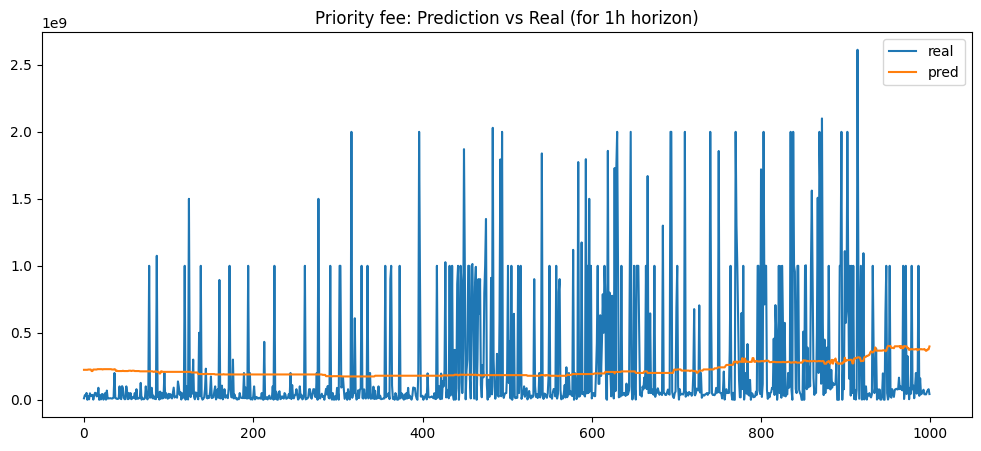

In [24]:
plt.figure(figsize=(12,5))
plt.plot(y_test_1h.values[:1000], label="real")
plt.plot(lgbm_pred[:1000], label="pred")
plt.legend()
plt.title("Priority fee: Prediction vs Real (for 1h horizon)")
plt.show()

In [25]:
joblib.dump(lgbm_model_1h, 'models/priority/1h_priority_lgbm.pkl')

['models/priority/1h_priority_lgbm.pkl']

## Модель прогноза комиссии через 1 день

In [26]:
df_1d = pd.read_parquet("data/models_datasets/priority/priority_1d.parquet")
df_1d.sort_values('height', ascending=True, inplace=True)
df_1d

,height,priority_min,priority_p25,priority_p50,priority_p90,priority_p95,priority_max,gas_limit,gas_used,transaction_count,...,lag_1d,lag_2d,ma_1d,ma_3d,vol_1d,spread_1d,tail_1d,eth_return_1d,eth_vol_1d,target
0,22292277,0,77000000,986732115,2000000000,2000000000,21000000000,35859553,10531487,162,...,89000000.0,674607833.0,5.343555e+08,5.589196e+08,1.275246e+09,4.419253e+09,7.639567e+10,-0.000948,9.344458,500000000.0
1,22292278,0,28747524,500000000,2000000000,2420000000,10078747524,35824535,13125026,189,...,150427335.0,115000000.0,5.344040e+08,5.588965e+08,1.275238e+09,4.419262e+09,7.639479e+10,-0.000372,9.344562,342064065.0
2,22292279,0,10000000,641150163,2000000000,10008121970,117755418798,35859518,15445029,176,...,500000000.0,0.0,5.344236e+08,5.588851e+08,1.275239e+09,4.420355e+09,7.640164e+10,-0.000372,9.344666,517564651.0
3,22292280,0,50000003,682227906,2000000000,2000000000,105932312549,35894536,14681117,193,...,100687418.0,139001048.0,5.345044e+08,5.589166e+08,1.275230e+09,4.419907e+09,7.641346e+10,-0.000372,9.344770,646379749.0
4,22292281,0,26578711,412446123,2000000000,2000000000,39936836624,35859484,14482778,226,...,109920299.0,10000000.0,5.345464e+08,5.589311e+08,1.275221e+09,4.419806e+09,7.640601e+10,-0.000166,9.344817,465116199.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2587812,24881454,0,1395747,1395747,213286608,1000000000,9453063802,60000000,27140196,567,...,89000000.0,20000000.0,1.545738e+08,1.240191e+08,4.397400e+08,2.117879e+09,2.549070e+10,-0.022180,24.464283,4001166.0
2587813,24881455,0,1395747,1395747,53283079,854814671,59854814671,60000000,38417793,785,...,5000000.0,56430000.0,1.545733e+08,1.240191e+08,4.397402e+08,2.117978e+09,2.549752e+10,-0.022180,24.467231,6422989.0
2587814,24881456,0,1395747,5000000,48190829,849722421,27334085618,60000000,48091149,1135,...,20968982.0,20000000.0,1.545710e+08,1.240193e+08,4.397409e+08,2.117821e+09,2.550107e+10,-0.022180,24.470176,50000000.0
2587815,24881457,0,1395747,1395747,216876144,1163847288,59838394530,60000000,41686431,530,...,13503033.0,2760000.0,1.545694e+08,1.240184e+08,4.397414e+08,2.117706e+09,2.550868e+10,-0.022180,24.473119,5057452.0


In [27]:
drop_cols = [
    "height"
]

df_1d = df_1d.drop(columns=drop_cols)

In [28]:
train_size_1d = int(len(df_1d) * 0.8)
val_size_1d = int(len(df_1d) * 0.1)

train_1d = df_1d.iloc[:train_size_1d]
val_1d = df_1d.iloc[train_size_1h:train_size_1d + val_size_1d]
test_1d = df_1d.iloc[train_size_1d + val_size_1d:]

In [29]:
X_train_1d = train_1d.drop(columns=[target_column_name])
y_train_1d = train_1d[target_column_name]

X_val_1d = df_1d.drop(columns=[target_column_name])
y_val_1d = df_1d[target_column_name]

X_test_1d = test_1d.drop(columns=[target_column_name])
y_test_1d = test_1d[target_column_name]

In [30]:
lgbm_model_1d = LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.001,
    max_depth=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm_model_1d.fit(
    X_train_1d,
    y_train_1d,
    eval_set=[(X_val_1d, y_val_1d)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(50)  # вывод каждые 50 итераций
    ]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029014 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6954
[LightGBM] [Info] Number of data points in the train set: 2070253, number of used features: 32
[LightGBM] [Info] Start training from score 374184606.296489
Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 2.86748e+09	valid_0's l2: 8.22242e+18
[100]	valid_0's rmse: 2.86475e+09	valid_0's l2: 8.20677e+18
[150]	valid_0's rmse: 2.86205e+09	valid_0's l2: 8.19134e+18
[200]	valid_0's rmse: 2.85964e+09	valid_0's l2: 8.17753e+18
[250]	valid_0's rmse: 2.85738e+09	valid_0's l2: 8.16461e+18
[300]	valid_0's rmse: 2.85513e+09	valid_0's l2: 8.15176e+18
[350]	valid_0's rmse: 2.8529e+09	valid_0's l2: 8.13905e+18
[400]	valid_0's rmse: 2.85092e+09	valid_0's l2: 8.12776e+18
[450]	valid_0's rmse: 2.84898e+09	valid_0's l

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,50
,learning_rate,0.001
,n_estimators,5000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [31]:
lgbm_pred = lgbm_model_1d.predict(X_test_1d)

lgbm_mae = mean_absolute_error(y_test_1d, lgbm_pred)
lgbm_rmse = np.sqrt(mean_squared_error(y_test_1d, lgbm_pred))

print("MAE:", lgbm_mae)
print("RMSE:", lgbm_rmse)

MAE: 268875572.92004645
RMSE: 5507380704.055865


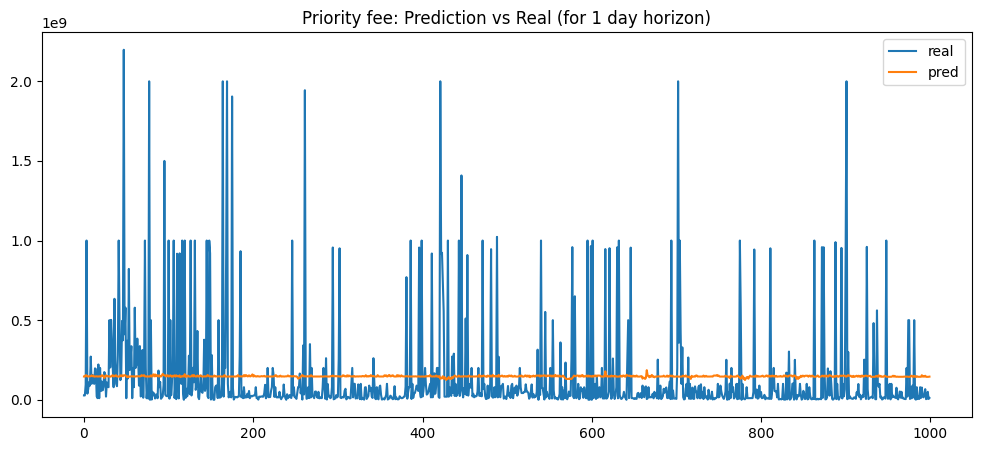

In [33]:
plt.figure(figsize=(12,5))
plt.plot(y_test_1d.values[-1000:], label="real")
plt.plot(lgbm_pred[-1000:], label="pred")
plt.legend()
plt.title("Priority fee: Prediction vs Real (for 1 day horizon)")
plt.show()

In [34]:
joblib.dump(lgbm_model_1d, 'models/priority/1d_priority_lgbm.pkl')

['models/priority/1d_priority_lgbm.pkl']

## Модель прогноза комиссии через 1 день

In [36]:
df_1w = pd.read_parquet("data/models_datasets/priority/priority_1w.parquet")
df_1w.sort_values('height', ascending=True, inplace=True)
df_1w

,height,priority_min,priority_p25,priority_p50,priority_p90,priority_p95,priority_max,gas_limit,gas_used,transaction_count,...,ma_7d,trend_week,vol_1d,vol_7d,spread_7d,tail_7d,eth_return_7d,eth_vol_7d,week_of_year,target
0,22321096,0,8404006,89000000,2000000000,2147150342,68290953011,35964845,10350596,140,...,5.025258e+08,-3.354544e+05,5.758097e+08,2.574283e+09,5.233038e+09,6.241995e+10,-0.037186,21.040117,17,2.543681e+08
1,22321097,0,18015481,103045003,2000000000,5010000000,10020813939,35929725,30337380,131,...,5.025102e+08,-5.091993e+05,5.757168e+08,2.574283e+09,5.233114e+09,6.241894e+10,-0.037432,21.040413,17,5.523506e+08
2,22321098,0,18015481,90850000,2000000000,2000000000,3876371478,35964811,5470527,90,...,5.025120e+08,-7.032291e+05,5.756230e+08,2.574282e+09,5.233052e+09,6.241848e+10,-0.037432,21.040708,17,1.000000e+09
3,22321099,0,1000000,279566450,6065435090,6559581742,16000000000,35999931,12375446,86,...,5.025156e+08,-7.374017e+05,5.756289e+08,2.574282e+09,5.233139e+09,6.241762e+10,-0.037432,21.041003,17,9.798102e+07
4,22321100,0,76603647,500000000,6072366086,6077755086,70696901738,36000000,35981805,217,...,5.025156e+08,-7.374017e+05,5.756289e+08,2.574282e+09,5.233220e+09,6.241877e+10,-0.037432,21.041299,17,2.253800e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2515811,24838244,0,6214217,12125502,1000000000,2000000000,3001610882,60000000,42528525,347,...,1.212799e+08,1.520073e+07,3.623741e+08,3.641507e+08,2.203026e+09,2.104743e+10,0.018838,64.563847,15,4.001166e+06
2515812,24838245,0,70000,1000000,260897700,1945096574,4938567830,60000000,54838535,507,...,1.212797e+08,1.517505e+07,3.623771e+08,3.641507e+08,2.203025e+09,2.104743e+10,0.018838,64.564663,15,6.422989e+06
2515813,24838246,0,1,200000000,2000000000,2008000000,8296776825,60000000,11409824,99,...,1.212777e+08,1.515485e+07,3.623683e+08,3.641500e+08,2.203025e+09,2.104748e+10,0.017795,64.565420,15,5.000000e+07
2515814,24838247,0,175000,6269944,1000000000,2000000000,5000000000,60000000,50742529,401,...,1.212607e+08,1.515605e+07,3.623715e+08,3.641354e+08,2.203028e+09,2.104739e+10,0.018281,64.566192,15,5.057452e+06


In [37]:
drop_cols = [
    "height"
]

df_1w = df_1w.drop(columns=drop_cols)

In [38]:
train_size_1w = int(len(df_1w) * 0.8)
val_size_1w = int(len(df_1w) * 0.1)

train_1w = df_1w.iloc[:train_size_1w]
val_1w = df_1w.iloc[train_size_1w:train_size_1w + val_size_1w]
test_1w = df_1w.iloc[train_size_1w + val_size_1w:]

In [39]:
X_train_1w = train_1w.drop(columns=[target_column_name])
y_train_1w = train_1w[target_column_name]

X_val_1w = val_1w.drop(columns=[target_column_name])
y_val_1w = val_1w[target_column_name]

X_test_1w = test_1w.drop(columns=[target_column_name])
y_test_1w = test_1w[target_column_name]

In [40]:
lgbm_model_1w = LGBMRegressor(
    n_estimators=50000,
    learning_rate=0.01,
    max_depth=30,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm_model_1w.fit(
    X_train_1w,
    y_train_1w,
    eval_set=[(X_val_1w, y_val_1w)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(50)  # вывод каждые 50 итераций
    ]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.036473 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7503
[LightGBM] [Info] Number of data points in the train set: 2012652, number of used features: 35
[LightGBM] [Info] Start training from score 367471237.468394
Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 1.00957e+09	valid_0's l2: 1.01923e+18
[100]	valid_0's rmse: 1.00647e+09	valid_0's l2: 1.01298e+18
[150]	valid_0's rmse: 1.00688e+09	valid_0's l2: 1.0138e+18
Early stopping, best iteration is:
[142]	valid_0's rmse: 1.00567e+09	valid_0's l2: 1.01137e+18


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,30
,learning_rate,0.01
,n_estimators,50000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [41]:
lgbm_pred = lgbm_model_1w.predict(X_test_1w)

lgbm_mae = mean_absolute_error(y_test_1w, lgbm_pred)
lgbm_rmse = np.sqrt(mean_squared_error(y_test_1w, lgbm_pred))

print("MAE:", lgbm_mae)
print("RMSE:", lgbm_rmse)

MAE: 259965911.08429047
RMSE: 5583350060.742891


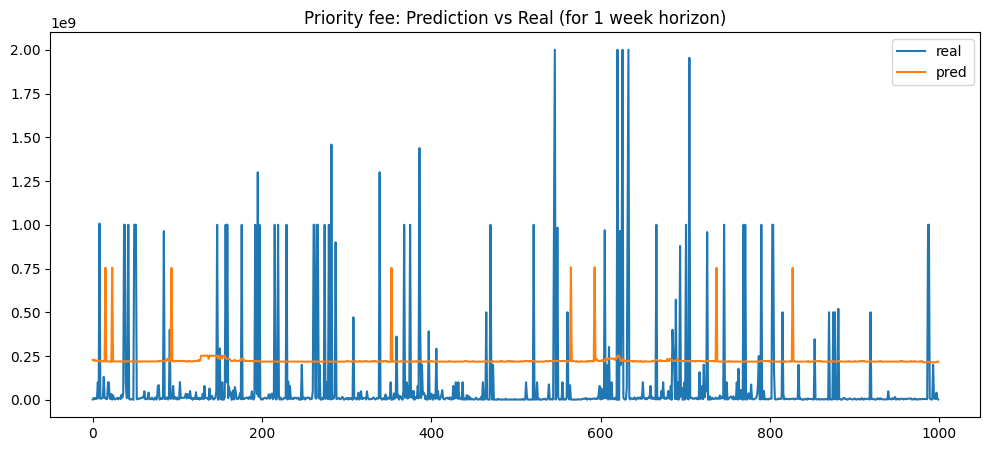

In [42]:
plt.figure(figsize=(12,5))
plt.plot(y_test_1w.values[:1000], label="real")
plt.plot(lgbm_pred[:1000], label="pred")
plt.legend()
plt.title("Priority fee: Prediction vs Real (for 1 week horizon)")
plt.show()

In [43]:
joblib.dump(lgbm_model_1w, 'models/priority/1w_priority_lgbm.pkl')

['models/priority/1w_priority_lgbm.pkl']